**1. Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')



# Load data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Supply Demand/Uber_Supply_Demand_Cleaned.csv')

# Display basic information
print(df.head())
print(df.info())
print(df.describe())

Mounted at /content/drive
   Request_id Pickup_point  Driver_id          Status    Request_timestamp  \
0         619      Airport        1.0  Trip Completed  2016-07-11 11:51:00   
1         867      Airport        1.0  Trip Completed  2016-07-11 17:57:00   
2        1807         City        1.0  Trip Completed  2016-07-12 09:17:00   
3        2532      Airport        1.0  Trip Completed  2016-07-12 21:08:00   
4        3112         City        1.0  Trip Completed  2016-07-13 08:33:16   

        Drop_timestamp        Date  Hour    Weekday Time_Slot Driver_Assigned  \
0  2016-07-11 13:00:00  2016-07-11    11     Monday   Morning             Yes   
1  2016-07-11 18:47:00  2016-07-11    17     Monday   Evening             Yes   
2  2016-07-12 09:58:00  2016-07-12     9    Tuesday   Morning             Yes   
3  2016-07-12 22:03:00  2016-07-12    21    Tuesday   Evening             Yes   
4  2016-07-13 09:25:47  2016-07-13     8  Wednesday   Morning             Yes   

   Trip_Duration_M

**2. Dataset Overview**

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

Rows: 6745
Columns: 12

Missing Values:
Request_id                  0
Pickup_point                0
Driver_id                2650
Status                      0
Request_timestamp           0
Drop_timestamp           3914
Date                        0
Hour                        0
Weekday                     0
Time_Slot                   0
Driver_Assigned             0
Trip_Duration_Minutes    3914
dtype: int64


**Findings:**

Total records = 6745

Features = 12

**Major status categories:**

Trip Completed

Cancelled

No Cars Available

**3. Trip Status Distribution**

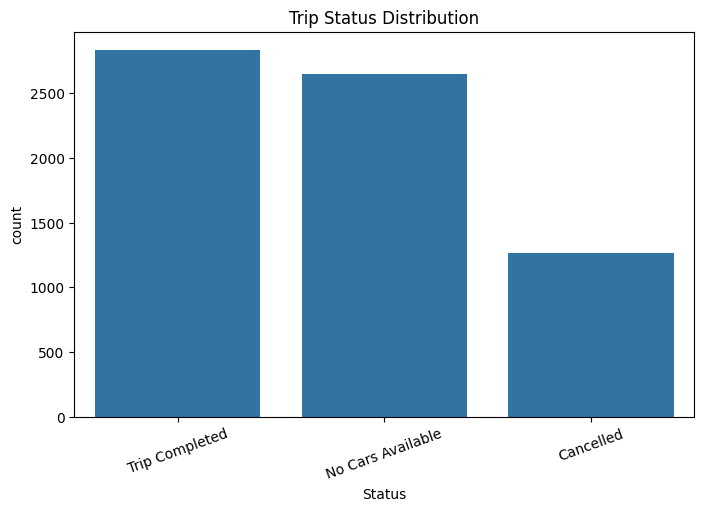

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Status',
    order=df['Status'].value_counts().index
)

plt.title("Trip Status Distribution")
plt.xticks(rotation=20)
plt.show()

**Insights:**

Trip Completed = 2831

No Cars Available = 2650

Cancelled = 1264

The biggest issue is vehicle unavailability, followed by cancellations.

**4. Requests by Pickup Point**

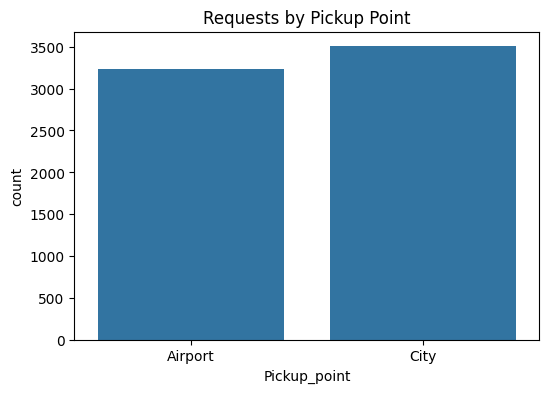

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Pickup_point'
)

plt.title("Requests by Pickup Point")
plt.show()

**Insights:**

City requests ≈ 3507

Airport requests ≈ 3238

Demand is almost equally distributed.

**5. Status vs Pickup Point**

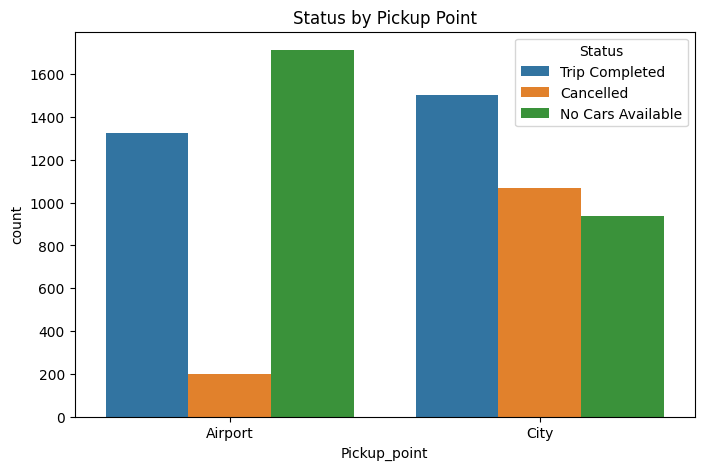

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Pickup_point',
    hue='Status'
)

plt.title("Status by Pickup Point")
plt.show()

**Key Business Insight:**

Pickup Point	Main Problem

Airport	No Cars Available

City	Cancellations

Airport suffers from a severe supply shortage.

**6. Hourly Demand Analysis**

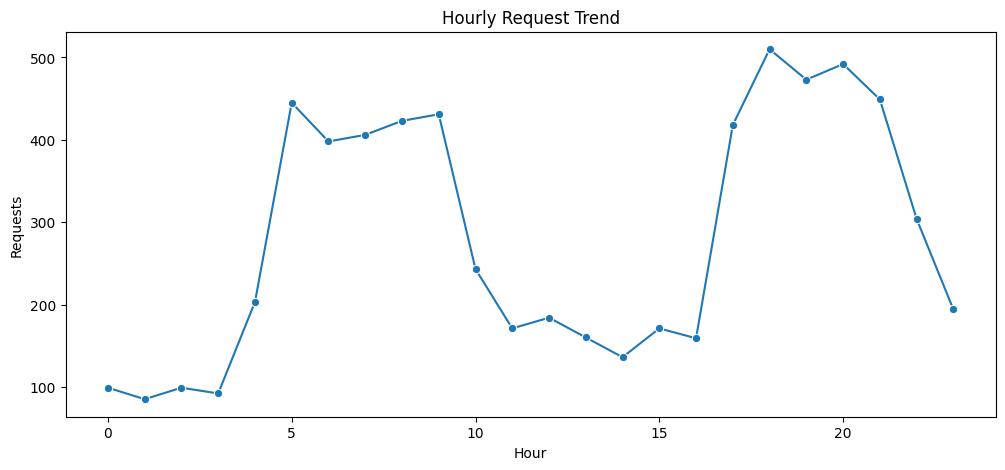

In [ ]:
hourly_requests = df.groupby('Hour')['Request_id'].count()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_requests.index,
    y=hourly_requests.values,
    marker='o'
)

plt.title("Hourly Request Trend")
plt.xlabel("Hour")
plt.ylabel("Requests")
plt.show()

**Peak Demand Hours:**

Morning: 5 AM – 9 AM

Evening: 5 PM – 9 PM

**Highest demand around:**

6 PM

8 PM

7 PM

**7. Status by Hour**

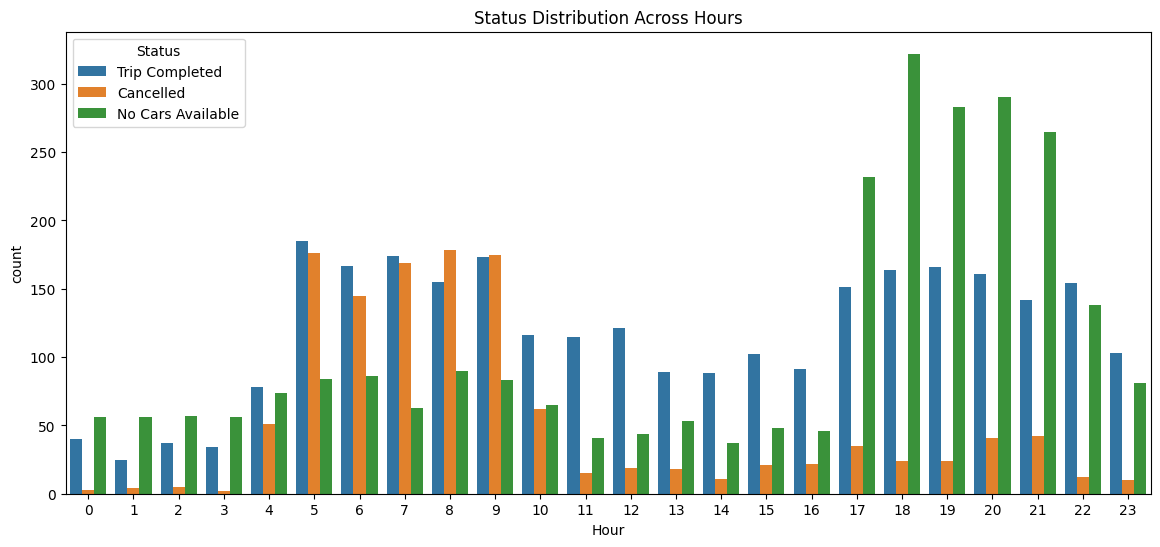

In [ ]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x='Hour',
    hue='Status'
)

plt.title("Status Distribution Across Hours")
plt.show()

**Insights:**

**Morning (5–9 AM):**

More cancellations.

Drivers cancel trips from city.

**Evening (5–9 PM):**

Huge number of "No Cars Available".

Demand exceeds supply.

**8. Time Slot Analysis**

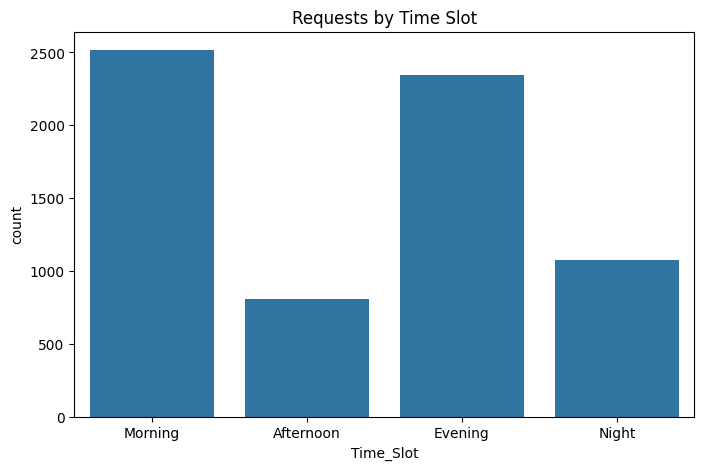

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Time_Slot',
    order=['Morning','Afternoon','Evening','Night']
)

plt.title("Requests by Time Slot")
plt.show()

**9. Time Slot vs Status**

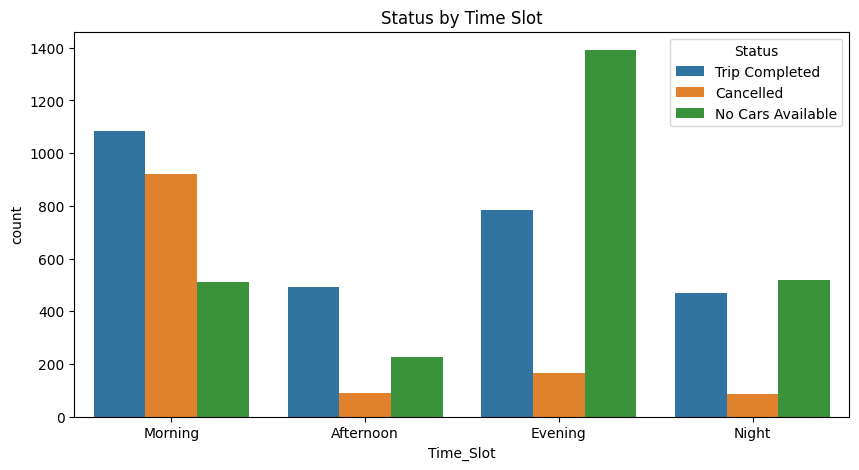

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Time_Slot',
    hue='Status',
    order=['Morning','Afternoon','Evening','Night']
)

plt.title("Status by Time Slot")
plt.show()

**Insights:**

**Morning:**

High cancellation rate.

**Evening:**

Highest "No Cars Available".

This indicates driver shortage during airport demand spikes.

**10. Weekday Analysis**

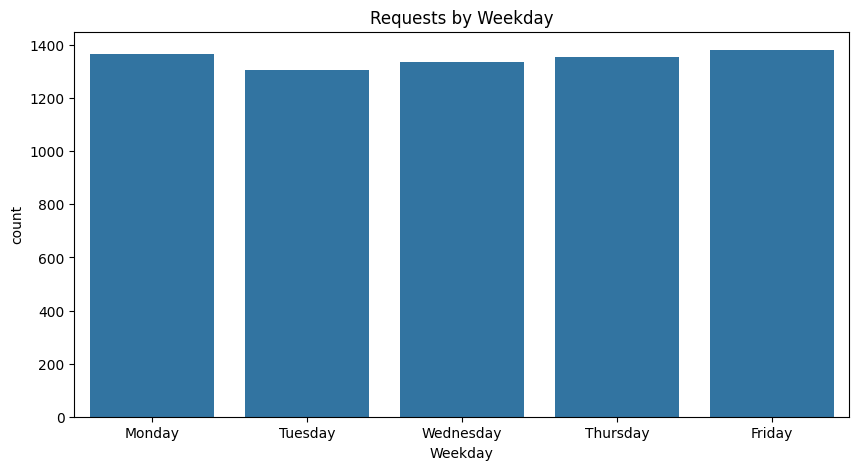

In [ ]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday'
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Weekday',
    order=weekday_order
)

plt.title("Requests by Weekday")
plt.show()

**11. Trip Duration Analysis**

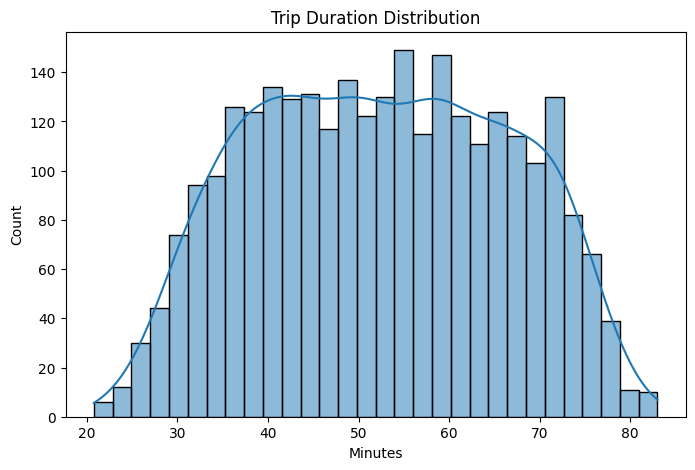

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Trip_Duration_Minutes'].dropna(),
    bins=30,
    kde=True
)

plt.title("Trip Duration Distribution")
plt.xlabel("Minutes")
plt.show()

**Insights:**

Most trips take 30–60 minutes.

Few long-duration trips create right-skewness.

**12. Average Trip Duration by Pickup Point**

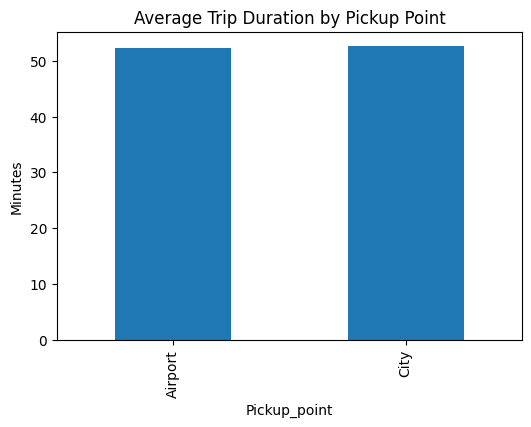

In [ ]:
avg_duration = df.groupby('Pickup_point')['Trip_Duration_Minutes'].mean()

avg_duration.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Average Trip Duration by Pickup Point")
plt.ylabel("Minutes")
plt.show()

**13. Driver Availability Analysis**

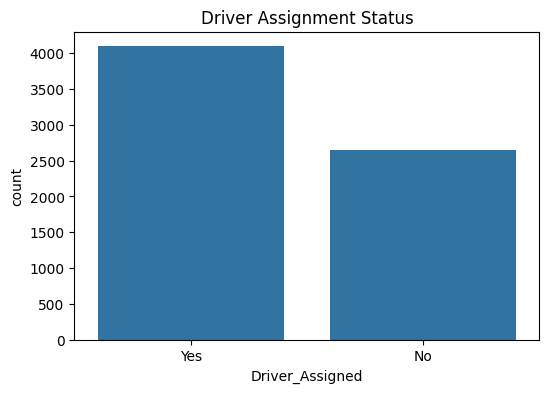

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Driver_Assigned'
)

plt.title("Driver Assignment Status")
plt.show()

**14. Demand-Supply Gap Analysis**

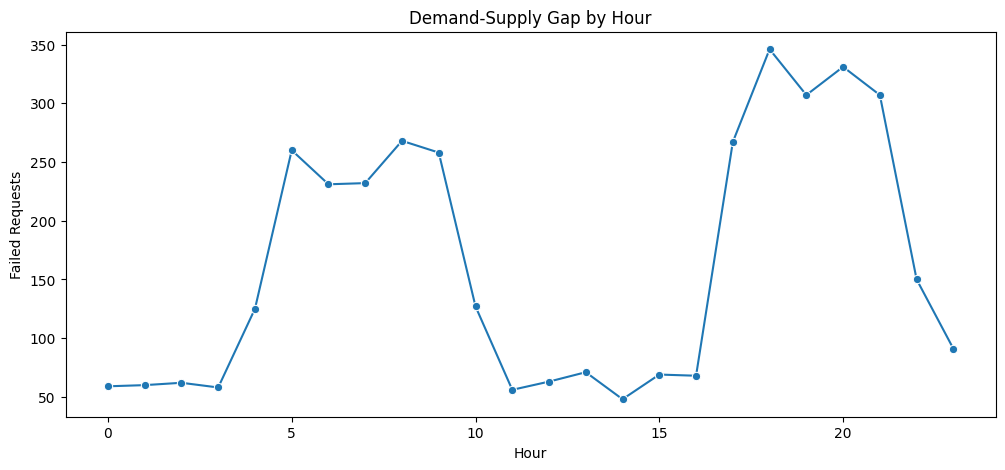

In [ ]:
df['Demand_Supply_Gap'] = df['Status'].apply(
    lambda x: 1 if x != 'Trip Completed' else 0
)

gap_by_hour = df.groupby('Hour')['Demand_Supply_Gap'].sum()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=gap_by_hour.index,
    y=gap_by_hour.values,
    marker='o'
)

plt.title("Demand-Supply Gap by Hour")
plt.xlabel("Hour")
plt.ylabel("Failed Requests")
plt.show()

**Insight:**

The highest demand-supply gap occurs:

5–9 AM

5–10 PM

**Final Business Conclusions:**

**Problem 1:** City → Airport (Morning)

High trip cancellations.

Drivers may avoid long airport trips.

**Problem 2:** Airport → City (Evening)

Massive "No Cars Available" cases.

Drivers are insufficient at the airport.

**Problem 3:** Peak Hours

**Demand spikes at:**

5 AM – 9 AM

5 PM – 10 PM

**Recommendations**

Increase driver incentives during peak hours.

Deploy more drivers near airports in evenings.

Offer surge pricing during demand spikes.

Reduce cancellations using driver acceptance rewards.

Improve airport driver allocation strategy.